# *Importing Libaries*

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Train test split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# *Dataset loaded*

In [2]:
data = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\PROJECT [DS]\Movie\IMDB Dataset.csv")

In [3]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


# *Checking Data*

In [4]:
data.shape

(50000, 2)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(418)

In [8]:
data['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

# *Data Cleaning*

In [9]:
data = data.drop_duplicates()

In [10]:
data.duplicated().sum()

np.int64(0)

# *Convert Reviews to Lowercase*

In [11]:
data['review'] = data['review'].str.lower()

C:\Users\HP\AppData\Local\Temp\ipykernel_14636\3327899322.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['review'] = data['review'].str.lower()


In [12]:
data['review'][0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.<br /><br />it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />i would say the main appeal of the show is due to the fa

# *Removing HTML Tags*

In [13]:
data['review'].str.contains('<br').sum()

np.int64(28966)

In [14]:
data['review'] = data['review'].apply(lambda x: re.sub(r'<.*?>', '', x))

C:\Users\HP\AppData\Local\Temp\ipykernel_14636\4024296505.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['review'] = data['review'].apply(lambda x: re.sub(r'<.*?>', '', x))


In [15]:
data['review'].str.contains('<br').sum()

np.int64(0)

In [16]:
data['review'][0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows wo

# *Removing URLs*

In [17]:
data['review'].str.contains('http').sum()

np.int64(121)

In [18]:
data['review'] = data['review'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))

C:\Users\HP\AppData\Local\Temp\ipykernel_14636\3878332225.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['review'] = data['review'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))


In [19]:
data['review'].str.contains('http').sum()

np.int64(0)

In [20]:
data['review'][0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows wo

# *Handling English Contractions*

In [21]:
from collections import Counter

short_words = []
for review in data['review']:
    for word in review.split():
        if len(word) <= 3:
            short_words.append(word)
Counter(short_words).most_common()

[('the', 635594),
 ('a', 314589),
 ('and', 311551),
 ('of', 284640),
 ('to', 262664),
 ('is', 203503),
 ('in', 178720),
 ('i', 141274),
 ('it', 128888),
 ('was', 92503),
 ('as', 87770),
 ('for', 83952),
 ('but', 77439),
 ('on', 62445),
 ('are', 56598),
 ('his', 56570),
 ('not', 56363),
 ('you', 55161),
 ('he', 50840),
 ('be', 50466),
 ('at', 44971),
 ('one', 44730),
 ('by', 43086),
 ('an', 42003),
 ('all', 38391),
 ('who', 38048),
 ('so', 35770),
 ('or', 33049),
 ('has', 32379),
 ('her', 30999),
 ('if', 30744),
 ('out', 28759),
 ('my', 23415),
 ('she', 23247),
 ('no', 22220),
 ('had', 21438),
 ('up', 21257),
 ('can', 21161),
 ('see', 20715),
 ('we', 18227),
 ('-', 18149),
 ('get', 17555),
 ('how', 16667),
 ('do', 15656),
 ('its', 15544),
 ('me', 15387),
 ('any', 14617),
 ('bad', 13378),
 ('him', 12506),
 ('two', 12091),
 ('too', 11903),
 ('way', 11275),
 ('it.', 11112),
 ('did', 10946),
 ('off', 8956),
 ('say', 8759),
 ('go', 8742),
 ('why', 8642),
 ("i'm", 8237),
 ('few', 7650),
 ('ma

In [22]:
pip install contractions

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import contractions

In [24]:
data['review'][0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows wo

In [25]:
data['review'] = data['review'].apply(lambda x: contractions.fix(x))

C:\Users\HP\AppData\Local\Temp\ipykernel_14636\1490741640.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['review'] = data['review'].apply(lambda x: contractions.fix(x))


In [26]:
data['review'][0]

'one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. them city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other show

In [27]:
from collections import Counter

short_words = []
for review in data['review']:
    for word in review.split():
        if len(word) <= 3:
            short_words.append(word)
Counter(short_words).most_common()

[('the', 635765),
 ('a', 314589),
 ('and', 311551),
 ('of', 285239),
 ('is', 269198),
 ('to', 263690),
 ('in', 178720),
 ('it', 160416),
 ('i', 160050),
 ('not', 114132),
 ('was', 96952),
 ('as', 87810),
 ('for', 83952),
 ('but', 77439),
 ('are', 66043),
 ('you', 63822),
 ('on', 62445),
 ('he', 56844),
 ('his', 56570),
 ('be', 50468),
 ('at', 44971),
 ('one', 44730),
 ('by', 43180),
 ('an', 42003),
 ('who', 39528),
 ('all', 38399),
 ('so', 35785),
 ('has', 33058),
 ('or', 33049),
 ('do', 31839),
 ('her', 30999),
 ('if', 30744),
 ('out', 28759),
 ('she', 26344),
 ('my', 23415),
 ('no', 22220),
 ('had', 21977),
 ('up', 21257),
 ('can', 21161),
 ('see', 20717),
 ('we', 20048),
 ('did', 19648),
 ('-', 18149),
 ('get', 17555),
 ('how', 16724),
 ('its', 15544),
 ('me', 15417),
 ('am', 14996),
 ('any', 14617),
 ('bad', 13378),
 ('him', 12506),
 ('two', 12091),
 ('too', 11903),
 ('way', 11304),
 ('it.', 11112),
 ('off', 8956),
 ('say', 8759),
 ('go', 8742),
 ('why', 8655),
 ('us', 8167),
 ('fe

# *Removing Special Characters + Numbers*

In [28]:
data['review'].str.contains(r'[^a-zA-Z\s]').sum()

np.int64(49577)

In [29]:
data['review'] = data['review'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', ' ', x))

C:\Users\HP\AppData\Local\Temp\ipykernel_14636\2403086006.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['review'] = data['review'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', ' ', x))


In [30]:
data['review'].str.contains(r'[^a-zA-Z\s]').sum()

np.int64(0)

In [31]:
data['review'][0]

'one of the other reviewers has mentioned that after watching just   oz episode you will be hooked  they are right  as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence  which set in right from the word go  trust me  this is not a show for the faint hearted or timid  this show pulls no punches with regards to drugs  sex or violence  its is hardcore  in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary  it focuses mainly on emerald city  an experimental section of the prison where all the cells have glass fronts and face inwards  so privacy is not high on the agenda  them city is home to many  aryans  muslims  gangstas  latinos  christians  italians  irish and more    so scuffles  death stares  dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other show

# *Removing Extra Spaces*

In [32]:
data['review'].str.contains(r'\s{2,}').sum()

np.int64(49530)

In [33]:
data['review'] = data['review'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

C:\Users\HP\AppData\Local\Temp\ipykernel_14636\3804579739.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['review'] = data['review'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())


In [34]:
data['review'].str.contains(r'\s{2,}').sum()

np.int64(0)

In [35]:
data['review'][0]

'one of the other reviewers has mentioned that after watching just oz episode you will be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda them city is home to many aryans muslims gangstas latinos christians italians irish and more so scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows would not dare forget pre

# *Removaing Stopwords*

In [36]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

# *Removing Not/NO/NOR Words from stopwords List*

In [38]:
stop_words = stopwords.words('english')

In [39]:
stop_words.remove('not')

In [40]:
stop_words

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'only',
 'o

In [41]:
data['review'] = data['review'].apply(lambda x: " ".join(word for word in x.split() if word not in stop_words))

C:\Users\HP\AppData\Local\Temp\ipykernel_14636\1266767700.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['review'] = data['review'].apply(lambda x: " ".join(word for word in x.split() if word not in stop_words))


In [42]:
data['review'][0]

'one reviewers mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scenes violence set right word go trust not show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy not high agenda city home many aryans muslims gangstas latinos christians italians irish scuffles death stares dodgy dealings shady agreements never far away would say main appeal show due fact goes shows would not dare forget pretty pictures painted mainstream audiences forget charm forget romance oz not mess around first episode ever saw struck nasty surreal could not say ready watched developed taste oz got accustomed high levels graphic violence not violence injustice crooked guards sold nickel inmates kill order get away well mannered middle class inmates turned pri

# *Stemming [Stemmer = tool that converts words into root/base form*
# *(example= playing - play)]*

In [43]:
ps = PorterStemmer()

In [44]:
data['review'] = data['review'].apply(lambda x: " ".join(ps.stem(word) for word in x.split()))

C:\Users\HP\AppData\Local\Temp\ipykernel_14636\2969624205.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['review'] = data['review'].apply(lambda x: " ".join(ps.stem(word) for word in x.split()))


In [45]:
data['review'][0]

'one review mention watch oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust not show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call oz nicknam given oswald maximum secur state penitentari focus mainli emerald citi experiment section prison cell glass front face inward privaci not high agenda citi home mani aryan muslim gangsta latino christian italian irish scuffl death stare dodgi deal shadi agreement never far away would say main appeal show due fact goe show would not dare forget pretti pictur paint mainstream audienc forget charm forget romanc oz not mess around first episod ever saw struck nasti surreal could not say readi watch develop tast oz got accustom high level graphic violenc not violenc injustic crook guard sold nickel inmat kill order get away well manner middl class inmat turn prison bitch due lack street skill prison experi watch oz may becom comfort uncomfort view ge

# *Separating Features and Target Variable*

In [46]:
X = data['review']
y = data['sentiment']

In [47]:
X

0        one review mention watch oz episod hook right ...
1        wonder littl product film techniqu unassum old...
2        thought wonder way spend time hot summer weeke...
3        basic famili littl boy jake think zombi closet...
4        petter mattei love time money visual stun film...
                               ...                        
49995    thought movi right good job not creativ origin...
49996    bad plot bad dialogu bad act idiot direct anno...
49997    cathol taught parochi elementari school nun ta...
49998    go disagre previou comment side maltin one sec...
49999    one expect star trek movi high art fan expect ...
Name: review, Length: 49582, dtype: object

In [48]:
y

0        positive
1        positive
2        positive
3        negative
4        positive
           ...   
49995    positive
49996    negative
49997    negative
49998    negative
49999    negative
Name: sentiment, Length: 49582, dtype: object

# *Converting Target Variable into numbers*

In [49]:
y = y.map({'positive': 1,'negative': 0})

In [50]:
y

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 49582, dtype: int64

# *Converting text to numerice*

In [51]:
X

0        one review mention watch oz episod hook right ...
1        wonder littl product film techniqu unassum old...
2        thought wonder way spend time hot summer weeke...
3        basic famili littl boy jake think zombi closet...
4        petter mattei love time money visual stun film...
                               ...                        
49995    thought movi right good job not creativ origin...
49996    bad plot bad dialogu bad act idiot direct anno...
49997    cathol taught parochi elementari school nun ta...
49998    go disagre previou comment side maltin one sec...
49999    one expect star trek movi high art fan expect ...
Name: review, Length: 49582, dtype: object

In [52]:
tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1,2))

In [53]:
tfidf

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [99]:
corpus = data['review'].tolist()

In [100]:
X = tfidf.fit_transform(corpus)

In [101]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4498502 stored elements and shape (49582, 5000)>

# *Train Test Split*

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [103]:
X_train.shape, X_test.shape

((39665, 5000), (9917, 5000))

In [104]:
y_train.shape, y_test.shape

((39665,), (9917,))

# *Model Training Using LogisticRegression*

In [105]:
lr = LogisticRegression(max_iter=1000)

In [106]:
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [107]:
y_pred = lr.predict(X_test)

In [108]:
accuracy_score(y_test, y_pred) 

0.8914994453967934

In [109]:
confusion_matrix(y_test, y_pred)

array([[4331,  608],
       [ 468, 4510]])

In [110]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4939
           1       0.88      0.91      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



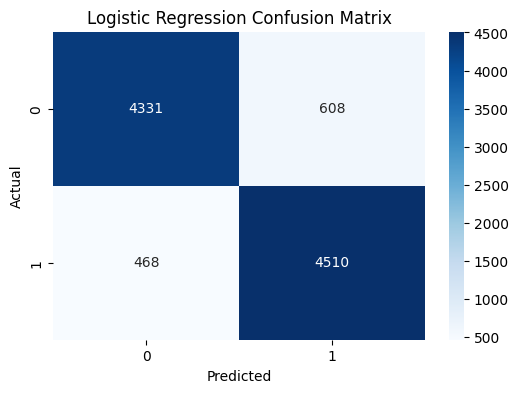

In [111]:
cm_lr = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# *Model Training using Decision Tree Classifier*

In [112]:
dt = DecisionTreeClassifier()

In [113]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [114]:
y_pred_dt = dt.predict(X_test)

In [115]:
accuracy_score(y_test, y_pred_dt) 

0.7139255823333669

In [116]:
confusion_matrix(y_test, y_pred_dt)

array([[3508, 1431],
       [1406, 3572]])

In [117]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.71      0.71      0.71      4939
           1       0.71      0.72      0.72      4978

    accuracy                           0.71      9917
   macro avg       0.71      0.71      0.71      9917
weighted avg       0.71      0.71      0.71      9917



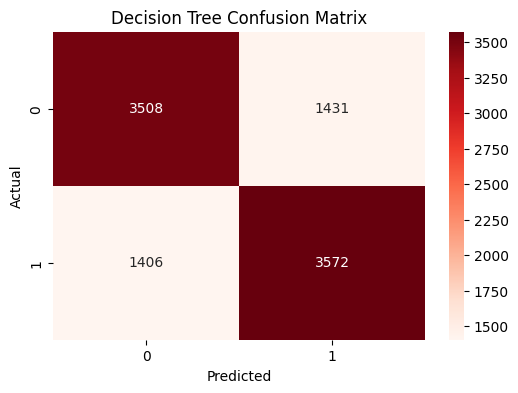

In [118]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt,annot=True,fmt='d',cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

# *Model Training using Random Forest Classifier*

In [119]:
rf = RandomForestClassifier(n_estimators=100)

In [120]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [121]:
y_pred_rf = rf.predict(X_test)

In [122]:
accuracy_score(y_test, y_pred_rf) 

0.8462236563476858

In [123]:
confusion_matrix(y_test, y_pred_rf)

array([[4156,  783],
       [ 742, 4236]])

In [124]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      4939
           1       0.84      0.85      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



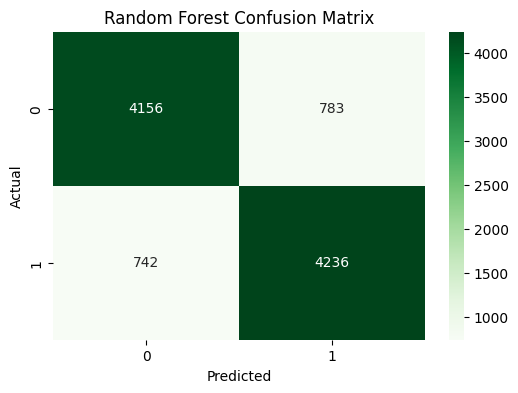

In [125]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

# *Model Accuracy Comparison Plot*

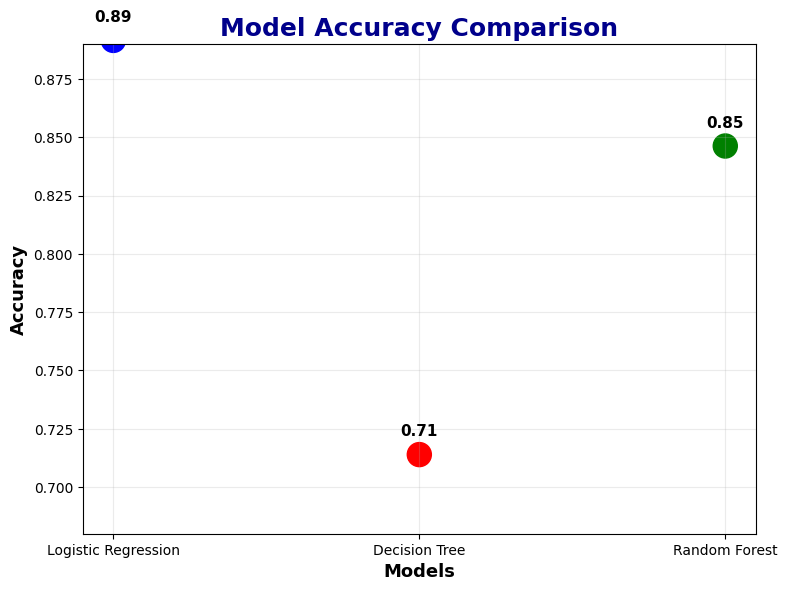

In [126]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred),accuracy_score(y_test, y_pred_dt),accuracy_score(y_test, y_pred_rf)]
plt.figure(figsize=(8,6))
plt.scatter(models,accuracies,s=300,color=['blue', 'red', 'green'])
for i, value in enumerate(accuracies):
    plt.text(i,value + 0.008,f"{value:.2f}",ha='center',fontsize=11,fontweight='bold')
plt.title("Model Accuracy Comparison",fontsize=18,fontweight='bold',color='darkblue')
plt.xlabel("Models",fontsize=13,fontweight='bold')
plt.ylabel("Accuracy",fontsize=13,fontweight='bold')
plt.ylim(0.68, 0.89)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# *Streamlit*

In [128]:
import pickle

pickle.dump(lr, open("model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))